**Implementation of Breast Cancer Detection Using Logistic Regression**

Import libraries
Load dataset

In [3]:
# Import libraries
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("data.csv")

# Remove unnecessary columns
df = df.drop(["id", "Unnamed: 32"], axis=1)

# Display first 5 rows
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
# Display dataset dimensions
df.shape

(569, 31)

In [5]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

## Encoding Target Values

In [6]:
## Encoding Target Values
df["diagnosis"] = df["diagnosis"].map({"M":1, "B":0})
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [7]:
# Separate input and output variables
X = df.drop("diagnosis", axis=1).values
y = df["diagnosis"].values.reshape(-1,1)

# Normalize feature values
X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

In [8]:
X.shape

(569, 30)

In [9]:
y.shape

(569, 1)

In [10]:
import numpy as np
# Function to add bias column
def add_bias(X):
    ones = np.ones((X.shape[0],1))
    X_aug = np.hstack((ones, X))
    return X_aug


# Add bias to input data
X = add_bias(X)

In [11]:
X.shape

(569, 31)

In [12]:
# Function to initialize weights
def initialize_weights(n_features):
    w = np.zeros((n_features,1))
    return w

# Initialize weight vector
w = initialize_weights(X.shape[1])

In [13]:
w.shape

(31, 1)

In [14]:
def sigmoid(z): # Defining Sigmoid Function 
    return 1 / (1 + np.exp(-z))

In [15]:
def predict(X, w): # prediction fxn
    z = X @ w
    y_hat = sigmoid(z)
    return y_hat

In [16]:
# Logistic Regression loss function

def compute_loss(y, y_hat): # loss fxn 
    n = len(y)
    eps = 1e-9
    loss = -(1/n) * np.sum(y*np.log(y_hat+eps) + (1-y)*np.log(1-y_hat+eps))
    return loss

## About the Loss Function

The loss function measures the error between actual and predicted values.

In Logistic Regression, Binary Cross Entropy Loss is used because it is suitable for binary classification problems.  
The small epsilon value (`eps`) is added to avoid log(0) errors during computation.

In [17]:
# Gradient computation function
def compute_gradient(X, y, y_hat): # gradient fxn 
    n = len(y)
    grad = (1/n) * (X.T @ (y_hat - y))
    return grad

In [18]:
# Weight update function
def update_weights(w, grad, lr): # weight update4 function 
    w = w - lr * grad
    return w

## Training the Logistic Regression Model

In [19]:
# Training function
def train(X, y, lr=0.01, iterations=5000): # training fxn 

    # Initialize weights
    w = initialize_weights(X.shape[1])
    losses = []

    # Training loop
    for i in range(iterations):

         # Predict probabilities
        y_hat = predict(X, w)

         # Compute loss
        loss = compute_loss(y, y_hat)
        losses.append(loss)

        # Compute gradients
        grad = compute_gradient(X, y, y_hat)

         # Update weights
        w = update_weights(w, grad, lr)


         # Print loss after every 100 iterations
        if i % 100 == 0:
            print("Iteration:", i, "Loss:", loss)

    return w, losses

## Model Training

In [20]:
weights, losses = train(X, y, lr=0.01, iterations=1000)

Iteration: 0 Loss: 0.6931471785599453
Iteration: 100 Loss: 0.2489145221806627
Iteration: 200 Loss: 0.18653598471667987
Iteration: 300 Loss: 0.15829205131170687
Iteration: 400 Loss: 0.14157088594299633
Iteration: 500 Loss: 0.13030286732067337
Iteration: 600 Loss: 0.12208830433978542
Iteration: 700 Loss: 0.11577402953775658
Iteration: 800 Loss: 0.11073248574784295
Iteration: 900 Loss: 0.10659066827895164


## Visualizing Loss Curve

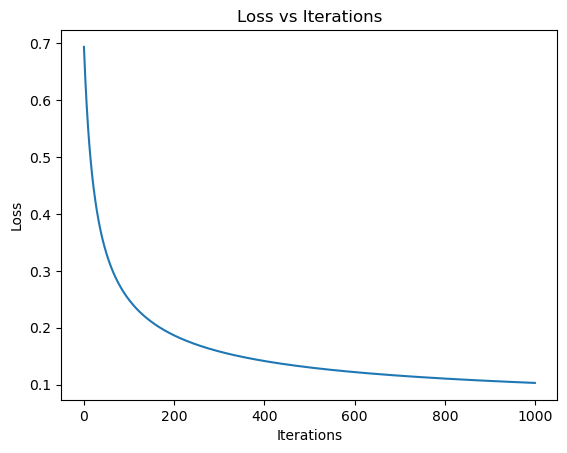

In [21]:
import matplotlib.pyplot as plt # Visualize Loss vs Iteration Graph
plt.plot(losses)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Loss vs Iterations")
plt.show()

## Predicting Class Labels

In [22]:
def predict_classes(X, w): # Predict classes

    probs = sigmoid(X @ w)
    
    return (probs >= 0.5).astype(int)

## Creating Confusion Matrix

In [23]:
def confusion_matrix(y, y_pred): # confusion matrix 

    TP = np.sum((y == 1) & (y_pred == 1))
    TN = np.sum((y == 0) & (y_pred == 0))
    FP = np.sum((y == 0) & (y_pred == 1))
    FN = np.sum((y == 1) & (y_pred == 0))

    return TP, TN, FP, FN

## Displaying Confusion Matrix

In [24]:
y_pred = predict_classes(X, weights)
TP, TN, FP, FN = confusion_matrix(y, y_pred)

print("Confusion Matrix")
print("TP:", TP)
print("FP:", FP)
print("FN:", FN)
print("TN:", TN)

Confusion Matrix
TP: 204
FP: 2
FN: 8
TN: 355


In [25]:
# Function to calculate accuracy
def accuracy(TP, TN, FP, FN):

    return (TP + TN) / (TP + TN + FP + FN)

In [26]:
# Function to calculate precision

def precision(TP, FP):

    return TP / (TP + FP)

In [27]:
# Function to calculate recall
def recall(TP, FN):

    return TP / (TP + FN)

In [28]:
#Function to calculate F1 score
def f1_score(p, r):

    return 2 * (p * r) / (p + r)

## Evaluating Model Performance

In [29]:
acc = accuracy(TP, TN, FP, FN)
prec = precision(TP, FP)
rec = recall(TP, FN)
f1 = f1_score(prec, rec)

print("\nAccuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)


Accuracy: 0.9824253075571178
Precision: 0.9902912621359223
Recall: 0.9622641509433962
F1 Score: 0.9760765550239234


In [30]:
# True Positive Rate
TPR = TP / (TP + FN)

# False Positive Rate
FPR = FP / (FP + TN)

# True Negative Rate
TNR = TN / (TN + FP)

# False Negative Rate
FNR = FN / (FN + TP)

# Display metrics
print("TPR:", TPR)
print("FPR:", FPR)
print("TNR:", TNR)
print("FNR:", FNR)

TPR: 0.9622641509433962
FPR: 0.0056022408963585435
TNR: 0.9943977591036415
FNR: 0.03773584905660377


## Plotting ROC Curve

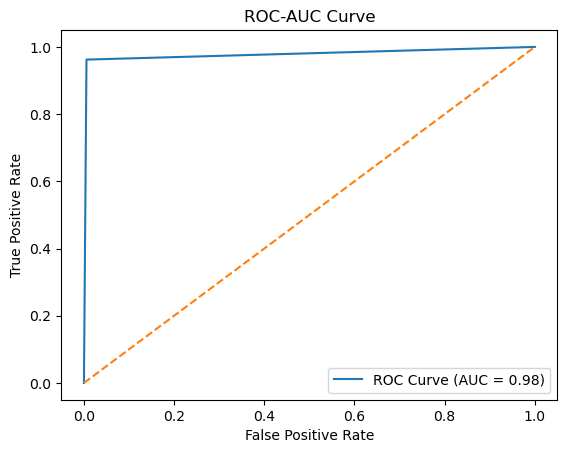

In [31]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y, y_pred)

# Compute AUC score
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.plot(fpr, tpr, label="ROC Curve (AUC = %0.2f)" % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')

# Graph labels
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve")

plt.legend()
plt.show()

## ROC-AUC Analysis

The ROC-AUC curve shows the performance of the Logistic Regression model.  
The obtained AUC score of 0.98 indicates excellent classification performance.